# 4.0 - Embeddings

In [2]:
#import
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

import umap
import umap.plot
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()
from sklearn.preprocessing import StandardScaler

In [2]:
# read data
df_cleaned = pd.read_parquet('../data/processed/cleaned_data.parquet', engine='pyarrow')

In [3]:
# setup model
model_name = "nickprock/sentence-bert-base-italian-xxl-uncased"
# enable model on mpu (- Apple Silicon GPU) or cuda (- Nvidia GPU) or cpu if no gpu is available
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)
tokenizer = AutoTokenizer.from_pretrained(model_name) #tokenizer
model = AutoModel.from_pretrained(model_name) #model
model.to(device) # move model to device

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(32102, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

---

In [40]:
# funtion to calculate the embeddings for each sentence
def sentence_embedding(tokenizer, model, device, sentences_list):
    # initialize list to store sentence embeddings
    sentence_embeddings = []

    for sentences in sentences_list:
        # sentence tokenizer
        encoded_input = tokenizer(sentences, padding = True, truncation = True, return_tensors = "pt")
        encoded_input = {key: val.to(device) for key, val in encoded_input.items()}

        # model inference
        with torch.no_grad():
            model_output = model(**encoded_input)

        # extract sentence embeddings
        sentence_embedding = model_output.last_hidden_state.mean(dim = 1)
        sentence_embeddings.append(sentence_embedding)

    # average the resulsts to obtain a single embedding for the article
    article_embedding = torch.cat(sentence_embeddings).mean(dim = 0).cpu().numpy()
    
    return article_embedding

# calculate embeddings
df_cleaned['sentence embeddings'] = df_cleaned['text chunked'].apply(
    lambda sentences: sentence_embedding(tokenizer, model, device, sentences)
)

In [ ]:
df_cleaned.to_parquet('../data/processed/embeddings.parquet', engine = 'pyarrow', index = False)

---

In [4]:
df_cleaned = pd.read_parquet('../data/processed/embeddings.parquet', engine = 'pyarrow')

In [14]:
topics = []
for _, row in df_cleaned.iterrows():
    for topic in row['topics']:
        if topic and topic not in topics:
            topics.append(topic)

def topic_embedding(tokenizer, model, topic):
    encoded_input = tokenizer(topic, return_tensors = "pt", padding = True, truncation = True)
    encoded_input = {key: val.to(device) for key, val in encoded_input.items()}

    # model inference
    with torch.no_grad():
        model_output = model(**encoded_input)

    # embeddings for the topic
    embedding = model_output.last_hidden_state.mean(dim = 1).squeeze().cpu().numpy()
    return embedding

df_topics = pd.DataFrame(topics, columns = ['topic'])
df_topics['embedding'] = df_topics['topic'].apply(lambda topic: topic_embedding(tokenizer, model, topic))


In [15]:
df_topics.rename(columns = {'embedding' : 'sentence embeddings'}, inplace = True)

In [16]:
df_all = pd.concat([df_cleaned[['id', 'sentence embeddings']], df_topics], axis = 0)

In [18]:
df_all['topic'] = df_all['topic'].fillna('article')

In [ ]:
embeddings_matrix = np.array(list(df_topics['embedding']))
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_matrix)

umap_reducer = umap.UMAP(n_components = 3, random_state = 42)
embeddings_reduced = umap_reducer.fit_transform(embeddings_scaled)
embeddings_reduced = umap_reducer.fit_transform(embeddings_matrix)

df_topics['embedding reduced'] = list(embeddings_reduced)

/Users/marcomanduca/miniconda3/envs/ai/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/marcomanduca/miniconda3/envs/ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/marcomanduca/miniconda3/envs/ai/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [97]:
df_topics['umap_x'] = embeddings_reduced[:, 0]
df_topics['umap_y'] = embeddings_reduced[:, 1]
df_topics['umap_z'] = embeddings_reduced[:, 2]

In [99]:
df_cleaned['sentence embeddings scaled'] = df_cleaned['sentence embeddings'].apply(
    lambda x: scaler.fit_transform(x.reshape(-1, 1)).reshape(-1)
)

In [100]:
#embeddings_scaled = np.array(list(df_cleaned['sentence embeddings']))
embeddings_scaled = np.array(list(df_cleaned['sentence embeddings scaled']))
#umap_reducer = umap.UMAP(n_components = 3, random_state = 42)
embedding_reduced = umap_reducer.fit_transform(embeddings_scaled)

/Users/marcomanduca/miniconda3/envs/ai/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [101]:
df_cleaned['umap_x'] = embedding_reduced[:, 0]
df_cleaned['umap_y'] = embedding_reduced[:, 1]
df_cleaned['umap_z'] = embedding_reduced[:, 2]

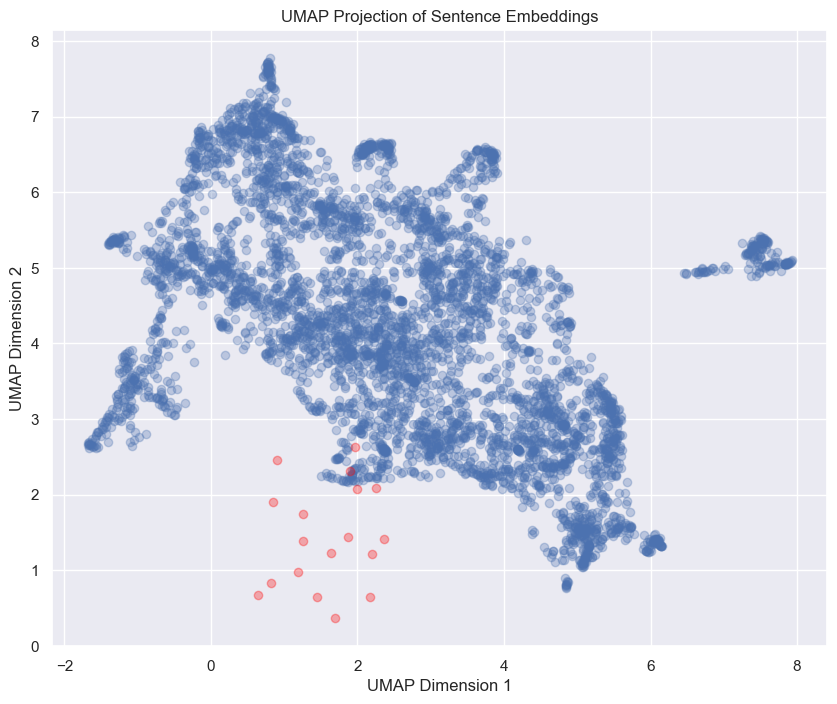

In [102]:
plt.figure(figsize=(10, 8))
plt.scatter(df_cleaned['umap_x'], df_cleaned['umap_y'], alpha = .3)
plt.scatter(df_topics['umap_x'], df_topics['umap_y'], alpha = 0.3, color = 'red')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('UMAP Projection of Sentence Embeddings')
plt.show()

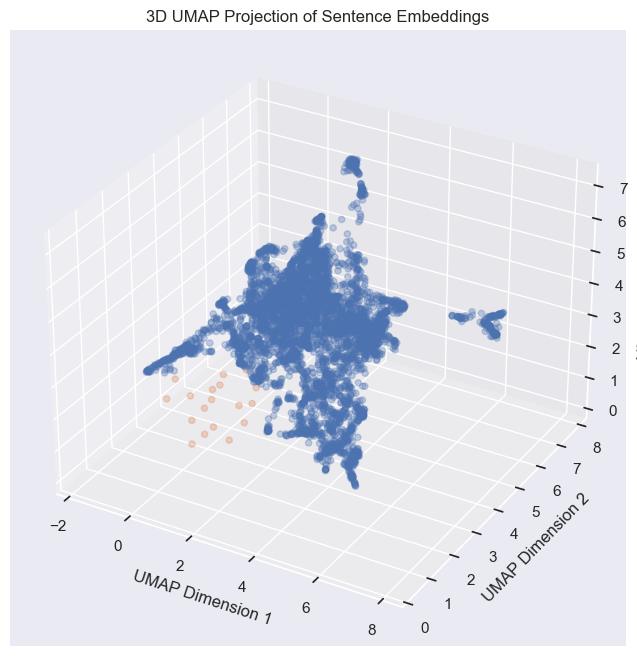

In [103]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection = '3d')
scatter = ax.scatter(
    df_cleaned['umap_x'], df_cleaned['umap_y'], df_cleaned['umap_z'],
    alpha = .3
)
scatter = ax.scatter(
    df_topics['umap_x'], df_topics['umap_y'], df_topics['umap_z'],
    alpha = .3
)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_zlabel('UMAP Dimension 3')
plt.title('3D UMAP Projection of Sentence Embeddings')
plt.show()